# Driver Monitoring System
## Notebook 02 — Fold Data Verification
---
**Goal:** Verify the ready-to-train numpy arrays before any model training.

Checks:
- Array shapes are correct
- Class balance per fold
- Feature value ranges after normalization
- LSTM and ML data verified separately

**Data location:** `data/ready/UAH-DRIVESET-v1/`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import os
os.chdir(r"D:\SPU\Lectures\y5_s2\Senior_Project_1\driver-monitoring-system")
print("Working directory:", os.getcwd())
# ── Config ────────────────────────────────────────────────
READY_DIR   = Path('data/ready/UAH-DRIVESET-v1')
WINDOWS     = ['w6s']
N_FOLDS     = 6
CLASS_NAMES = ['NORMAL', 'AGGRESSIVE', 'DROWSY']
CLASS_COLORS= ['steelblue', 'crimson', 'darkorange']

LSTM_FEATURES = [
    'ax_kf', 'ay_kf', 'az_kf',
    'roll', 'pitch', 'yaw', 'speed',
    'ax_kf_diff', 'ay_kf_diff', 'az_kf_diff',
    'speed_diff', 'acc_mag', 'yaw_diff'
]

# Plot style
plt.rcParams['figure.dpi']        = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.3
plt.rcParams['font.size']         = 10

print('Setup complete.')
print(f'Ready dir: {READY_DIR}')
print(f'Windows:   {WINDOWS}')
print(f'Folds:     {N_FOLDS}')

Working directory: D:\SPU\Lectures\y5_s2\Senior_Project_1\driver-monitoring-system
Setup complete.
Ready dir: data\ready\UAH-DRIVESET-v1
Windows:   ['w6s']
Folds:     6


---
## Part 1 — LSTM Data
Expected shape per fold: `(N, window_length, 13)`

In [15]:
print('LSTM Array Shapes')
print('=' * 65)
print(f'{"Window":<8} {"Fold":<6} {"X_train shape":<22} {"X_test shape":<22} {"y_train":<10} {"y_test"}')
print('-' * 65)

all_ok = True

for window in WINDOWS:
    for fold in range(1, N_FOLDS + 1):
        base = READY_DIR / window / f'fold{fold}' / 'lstm'

        if not base.exists():
            print(f'  {window:<6}  {fold:<4}  MISSING')
            all_ok = False
            continue

        X_train = np.load(base / 'X_train.npy')
        X_test  = np.load(base / 'X_test.npy')
        y_train = np.load(base / 'y_train.npy')
        y_test  = np.load(base / 'y_test.npy')

        # Check feature dimension
        feat_ok = X_train.shape[2] == 13
        flag    = '' if feat_ok else ' ← WRONG FEAT DIM'
        if not feat_ok:
            all_ok = False

        print(f'  {window:<6}  {fold:<4}  '
              f'{str(X_train.shape):<22} '
              f'{str(X_test.shape):<22} '
              f'{len(y_train):<10} '
              f'{len(y_test)}{flag}')

print()
if all_ok:
    print('All LSTM shapes look correct.')
else:
    print('WARNING: Some shapes are wrong. Check above.')

LSTM Array Shapes
Window   Fold   X_train shape          X_test shape           y_train    y_test
-----------------------------------------------------------------
  w6s     1     (25554, 60, 13)        (4712, 60, 13)         25554      4712
  w6s     2     (25092, 60, 13)        (5174, 60, 13)         25092      5174
  w6s     3     (24983, 60, 13)        (5283, 60, 13)         24983      5283
  w6s     4     (24781, 60, 13)        (5485, 60, 13)         24781      5485
  w6s     5     (25080, 60, 13)        (5186, 60, 13)         25080      5186
  w6s     6     (25840, 60, 13)        (4426, 60, 13)         25840      4426

All LSTM shapes look correct.


In [4]:
for window in WINDOWS:
    print(f'\nLSTM Class Balance — {window}')
    print('=' * 75)
    print(f'{"Fold":<6} {"Split":<8} {"NORMAL":>14} {"AGGRESSIVE":>14} {"DROWSY":>14} {"Total":>8}')
    print('-' * 75)

    for fold in range(1, N_FOLDS + 1):
        base = READY_DIR / window / f'fold{fold}' / 'lstm'
        for split in ['train', 'test']:
            y      = np.load(base / f'y_{split}.npy')
            counts = np.bincount(y, minlength=3)
            total  = len(y)
            print(f'  {fold:<4}  {split:<8}'
                  f'  {counts[0]:>6} ({counts[0]/total*100:.1f}%)'
                  f'  {counts[1]:>6} ({counts[1]/total*100:.1f}%)'
                  f'  {counts[2]:>6} ({counts[2]/total*100:.1f}%)'
                  f'  {total:>6}')
        print()


LSTM Class Balance — w6s
Fold   Split            NORMAL     AGGRESSIVE         DROWSY    Total
---------------------------------------------------------------------------
  1     train      10727 (42.0%)    6493 (25.4%)    8334 (32.6%)   25554
  1     test        2074 (44.0%)    1223 (26.0%)    1415 (30.0%)    4712

  2     train      10589 (42.2%)    6283 (25.0%)    8220 (32.8%)   25092
  2     test        2212 (42.8%)    1433 (27.7%)    1529 (29.6%)    5174

  3     train      10599 (42.4%)    6260 (25.1%)    8124 (32.5%)   24983
  3     test        2202 (41.7%)    1456 (27.6%)    1625 (30.8%)    5283

  4     train      10490 (42.3%)    6206 (25.0%)    8085 (32.6%)   24781
  4     test        2311 (42.1%)    1510 (27.5%)    1664 (30.3%)    5485

  5     train      10566 (42.1%)    6520 (26.0%)    7994 (31.9%)   25080
  5     test        2235 (43.1%)    1196 (23.1%)    1755 (33.8%)    5186

  6     train      11034 (42.7%)    6818 (26.4%)    7988 (30.9%)   25840
  6     test        

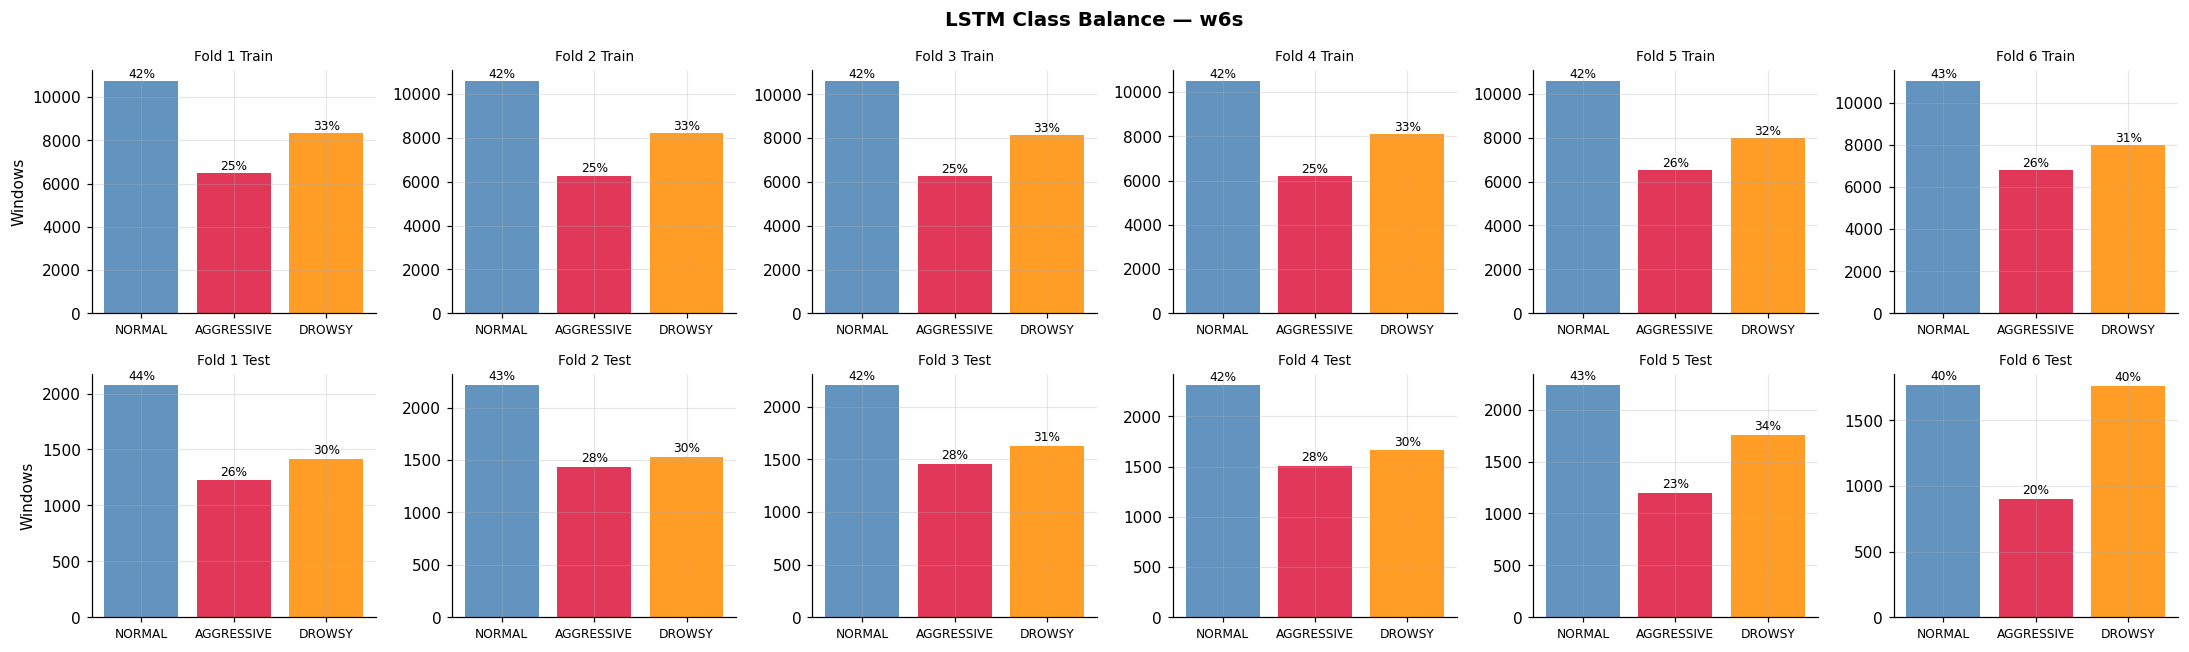

In [5]:
for window in WINDOWS:
    fig, axes = plt.subplots(2, N_FOLDS, figsize=(20, 6))
    fig.suptitle(f'LSTM Class Balance — {window}', fontsize=13, fontweight='bold')

    for fold in range(1, N_FOLDS + 1):
        base = READY_DIR / window / f'fold{fold}' / 'lstm'

        for row, split in enumerate(['train', 'test']):
            y      = np.load(base / f'y_{split}.npy')
            counts = np.bincount(y, minlength=3)
            pcts   = counts / len(y) * 100

            bars = axes[row, fold-1].bar(
                CLASS_NAMES, counts,
                color=CLASS_COLORS, alpha=0.85
            )

            # Add percentage labels on bars
            for bar, pct in zip(bars, pcts):
                axes[row, fold-1].text(
                    bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 20,
                    f'{pct:.0f}%',
                    ha='center', va='bottom', fontsize=8
                )

            axes[row, fold-1].set_title(f'Fold {fold} {split.capitalize()}', fontsize=9)
            axes[row, fold-1].set_ylabel('Windows' if fold == 1 else '')
            axes[row, fold-1].tick_params(axis='x', labelsize=8)

    plt.tight_layout()
    #plt.savefig(f'notebooks/lstm_class_balance_{window}.png', dpi=130, bbox_inches='tight')
    plt.show()
    #print(f'Saved: notebooks/lstm_class_balance_{window}.png')

In [16]:
# Check feature value ranges after normalization
# All features should have mean ≈ 0 and std ≈ 1

window = 'w6s'
fold   = 1
base   = READY_DIR / window / f'fold{fold}' / 'lstm'

X_train = np.load(base / 'X_train.npy')  # (N, window_length, 13)

print(f'LSTM Feature Value Ranges after Normalization')
print(f'Window={window}  Fold={fold}  X_train shape={X_train.shape}')
print('=' * 60)
print(f'{"Feature":<15} {"Min":>8} {"Max":>8} {"Mean":>8} {"Std":>8}')
print('-' * 60)

for i, feat in enumerate(LSTM_FEATURES):
    vals = X_train[:, :, i].flatten()
    flag = '  ← check' if abs(vals.mean()) > 0.5 or abs(vals.std() - 1) > 0.3 else ''
    print(f'  {feat:<13}  {vals.min():>8.3f}  {vals.max():>8.3f}'
          f'  {vals.mean():>8.3f}  {vals.std():>8.3f}{flag}')

print()


LSTM Feature Value Ranges after Normalization
Window=w6s  Fold=1  X_train shape=(25554, 60, 13)
Feature              Min      Max     Mean      Std
------------------------------------------------------------
  ax_kf            -8.977    10.204     0.000     1.001
  ay_kf            -8.434     4.927     0.000     1.000
  az_kf           -19.014     5.644     0.002     0.996
  roll             -9.091     7.095    -0.004     0.984
  pitch            -5.909     4.822    -0.000     1.000
  yaw              -1.996     1.999    -0.001     1.000
  speed            -5.559     3.603     0.010     0.992
  ax_kf_diff       -9.488    15.491     0.000     1.001
  ay_kf_diff      -10.123    18.872    -0.000     1.000
  az_kf_diff      -13.101    14.153     0.000     0.999
  speed_diff      -28.479    75.854    -0.008     0.743
  acc_mag          -0.761     8.585    -0.001     1.000
  yaw_diff        -87.949    87.947     0.000     0.987



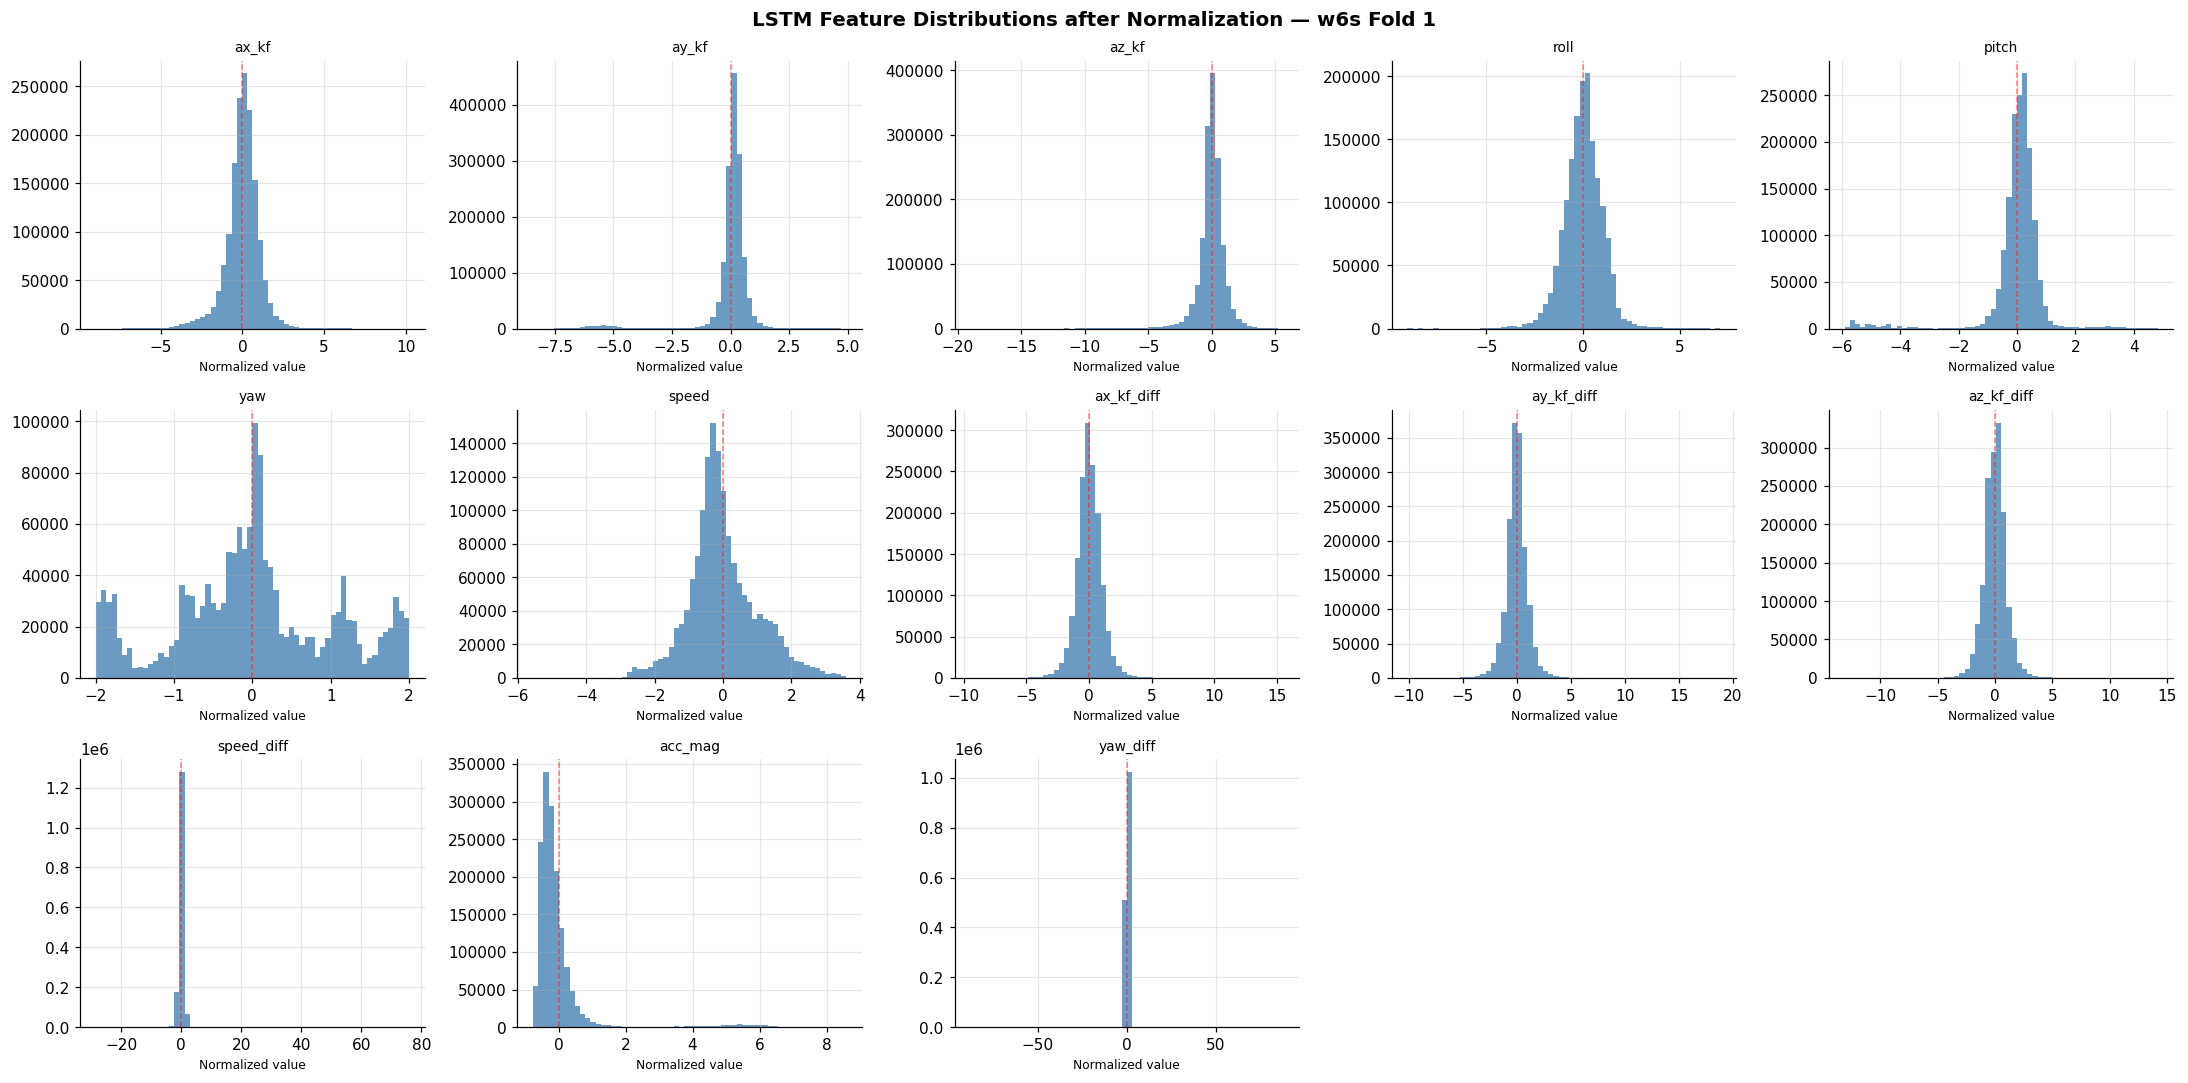

In [7]:
# Plot distribution of each feature for w3s fold1
window = 'w6s'
fold   = 1
base   = READY_DIR / window / f'fold{fold}' / 'lstm'
X_train = np.load(base / 'X_train.npy')

fig, axes = plt.subplots(3, 5, figsize=(20, 10))
fig.suptitle(f'LSTM Feature Distributions after Normalization — {window} Fold {fold}',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(LSTM_FEATURES):
    vals = X_train[:, :, i].flatten()
    axes[i].hist(vals, bins=60, color='steelblue', alpha=0.8, edgecolor='none')
    axes[i].set_title(feat, fontsize=9)
    axes[i].axvline(x=0, color='red', linewidth=1, linestyle='--', alpha=0.5)
    axes[i].set_xlabel('Normalized value', fontsize=8)

# Hide unused subplots
for j in range(len(LSTM_FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
#plt.savefig('notebooks/lstm_feature_distributions.png', dpi=130, bbox_inches='tight')
plt.show()
#print('Saved: notebooks/lstm_feature_distributions.png')

---
## Part 2 — ML Data
Expected shape per fold: `(N, 56)` — 8 signals × 7 statistics

In [17]:
print('ML Array Shapes')
print('=' * 65)
print(f'{"Window":<8} {"Fold":<6} {"X_train shape":<22} {"X_test shape":<22} {"y_train":<10} {"y_test"}')
print('-' * 65)

all_ok = True

for window in WINDOWS:
    for fold in range(1, N_FOLDS + 1):
        base = READY_DIR / window / f'fold{fold}' / 'ml'

        if not base.exists():
            print(f'  {window:<6}  {fold:<4}  MISSING')
            all_ok = False
            continue

        X_train = np.load(base / 'X_train.npy')
        X_test  = np.load(base / 'X_test.npy')
        y_train = np.load(base / 'y_train.npy')
        y_test  = np.load(base / 'y_test.npy')

        feat_ok = X_train.shape[1] == 91
        flag    = '' if feat_ok else ' ← WRONG FEAT DIM'
        if not feat_ok:
            all_ok = False

        print(f'  {window:<6}  {fold:<4}  '
              f'{str(X_train.shape):<22} '
              f'{str(X_test.shape):<22} '
              f'{len(y_train):<10} '
              f'{len(y_test)}{flag}')

print()

ML Array Shapes
Window   Fold   X_train shape          X_test shape           y_train    y_test
-----------------------------------------------------------------
  w6s     1     (25554, 91)            (4712, 91)             25554      4712
  w6s     2     (25092, 91)            (5174, 91)             25092      5174
  w6s     3     (24983, 91)            (5283, 91)             24983      5283
  w6s     4     (24781, 91)            (5485, 91)             24781      5485
  w6s     5     (25080, 91)            (5186, 91)             25080      5186
  w6s     6     (25840, 91)            (4426, 91)             25840      4426



In [9]:
for window in WINDOWS:
    print(f'\nML Class Balance — {window}')
    print('=' * 75)
    print(f'{"Fold":<6} {"Split":<8} {"NORMAL":>14} {"AGGRESSIVE":>14} {"DROWSY":>14} {"Total":>8}')
    print('-' * 75)

    for fold in range(1, N_FOLDS + 1):
        base = READY_DIR / window / f'fold{fold}' / 'ml'
        for split in ['train', 'test']:
            y      = np.load(base / f'y_{split}.npy')
            counts = np.bincount(y, minlength=3)
            total  = len(y)
            print(f'  {fold:<4}  {split:<8}'
                  f'  {counts[0]:>6} ({counts[0]/total*100:.1f}%)'
                  f'  {counts[1]:>6} ({counts[1]/total*100:.1f}%)'
                  f'  {counts[2]:>6} ({counts[2]/total*100:.1f}%)'
                  f'  {total:>6}')
        print()


ML Class Balance — w6s
Fold   Split            NORMAL     AGGRESSIVE         DROWSY    Total
---------------------------------------------------------------------------
  1     train      10727 (42.0%)    6493 (25.4%)    8334 (32.6%)   25554
  1     test        2074 (44.0%)    1223 (26.0%)    1415 (30.0%)    4712

  2     train      10589 (42.2%)    6283 (25.0%)    8220 (32.8%)   25092
  2     test        2212 (42.8%)    1433 (27.7%)    1529 (29.6%)    5174

  3     train      10599 (42.4%)    6260 (25.1%)    8124 (32.5%)   24983
  3     test        2202 (41.7%)    1456 (27.6%)    1625 (30.8%)    5283

  4     train      10490 (42.3%)    6206 (25.0%)    8085 (32.6%)   24781
  4     test        2311 (42.1%)    1510 (27.5%)    1664 (30.3%)    5485

  5     train      10566 (42.1%)    6520 (26.0%)    7994 (31.9%)   25080
  5     test        2235 (43.1%)    1196 (23.1%)    1755 (33.8%)    5186

  6     train      11034 (42.7%)    6818 (26.4%)    7988 (30.9%)   25840
  6     test        17

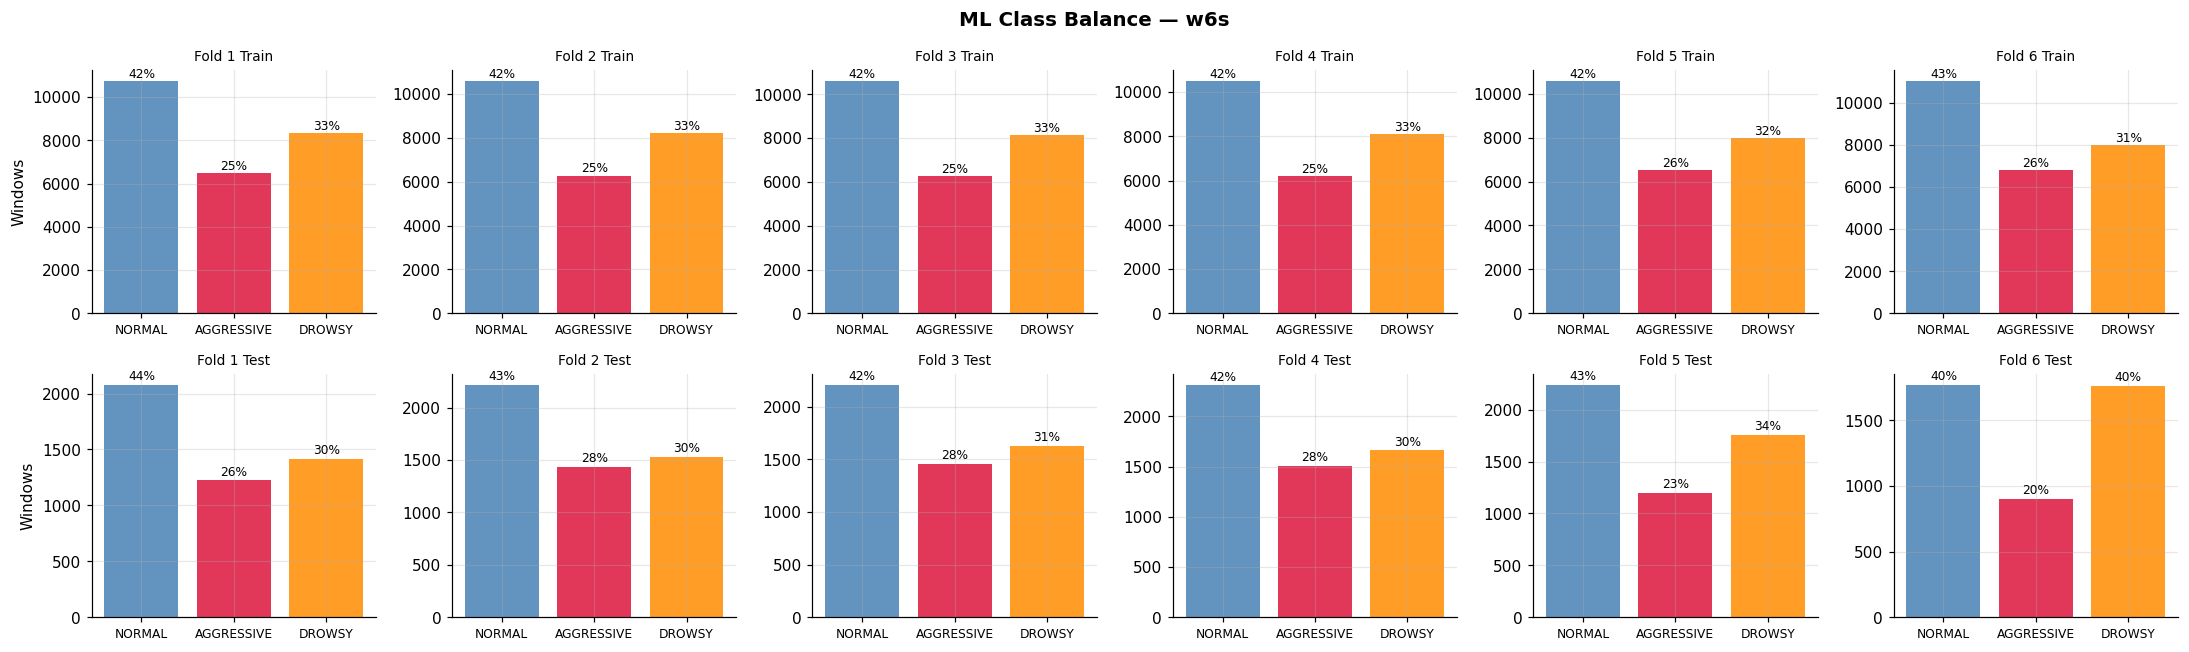

In [10]:
for window in WINDOWS:
    fig, axes = plt.subplots(2, N_FOLDS, figsize=(20, 6))
    fig.suptitle(f'ML Class Balance — {window}', fontsize=13, fontweight='bold')

    for fold in range(1, N_FOLDS + 1):
        base = READY_DIR / window / f'fold{fold}' / 'ml'

        for row, split in enumerate(['train', 'test']):
            y      = np.load(base / f'y_{split}.npy')
            counts = np.bincount(y, minlength=3)
            pcts   = counts / len(y) * 100

            bars = axes[row, fold-1].bar(
                CLASS_NAMES, counts,
                color=CLASS_COLORS, alpha=0.85
            )

            for bar, pct in zip(bars, pcts):
                axes[row, fold-1].text(
                    bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 20,
                    f'{pct:.0f}%',
                    ha='center', va='bottom', fontsize=8
                )

            axes[row, fold-1].set_title(f'Fold {fold} {split.capitalize()}', fontsize=9)
            axes[row, fold-1].set_ylabel('Windows' if fold == 1 else '')
            axes[row, fold-1].tick_params(axis='x', labelsize=8)

    plt.tight_layout()
    #plt.savefig(f'notebooks/ml_class_balance_{window}.png', dpi=130, bbox_inches='tight')
    plt.show()
    #print(f'Saved: notebooks/ml_class_balance_{window}.png')

In [11]:
# ML features are stats computed over windows
# Updated for 13 base signals -> 91 features total

ML_STAT_FEATURES = [
    "ax_kf", "ay_kf", "az_kf",
    "roll", "pitch", "yaw",
    "speed",
    "ax_kf_diff", "ay_kf_diff", "az_kf_diff",
    "speed_diff",
    "acc_mag",
    "yaw_diff"
]
STATS = ['mean', 'std', 'min', 'max', 'range', 'skew', 'kurt']

# Build column names in the correct order (Statistic-major)
ML_COL_NAMES = []
for stat in STATS:
    for feat in ML_STAT_FEATURES:
        ML_COL_NAMES.append(f'{feat}_{stat}')

window = 'w6s'
fold   = 1
base   = READY_DIR / window / f'fold{fold}' / 'ml'

X_train = np.load(base / 'X_train.npy')  # Now (N, 91)

print(f'ML Feature Value Ranges — {window} Fold {fold}')
print(f'X_train shape = {X_train.shape}')
print('=' * 65)
print(f'{"Column":<22} {"Min":>8} {"Max":>8} {"Mean":>8} {"Std":>8}')
print('-' * 65)

for i, col in enumerate(ML_COL_NAMES):
    vals = X_train[:, i]
    print(f'  {col:<20}  {vals.min():>8.3f}  {vals.max():>8.3f}'
          f'  {vals.mean():>8.3f}  {vals.std():>8.3f}')


ML Feature Value Ranges — w6s Fold 1
X_train shape = (25554, 91)
Column                      Min      Max     Mean      Std
-----------------------------------------------------------------
  ax_kf_mean              -3.766     1.001     0.000     0.495
  ay_kf_mean              -6.519     4.180     0.000     0.933
  az_kf_mean             -10.437     3.027     0.002     0.599
  roll_mean               -7.660     4.979    -0.004     0.861
  pitch_mean              -5.854     4.081    -0.000     0.975
  yaw_mean                -1.986     1.994    -0.001     0.989
  speed_mean              -2.755     3.540     0.010     0.985
  ax_kf_diff_mean         -0.202     0.214     0.000     0.024
  ay_kf_diff_mean         -0.555     0.497    -0.000     0.051
  az_kf_diff_mean         -0.756     0.729     0.000     0.052
  speed_diff_mean         -3.379     5.854    -0.008     0.408
  acc_mag_mean            -0.552     6.526    -0.001     0.948
  yaw_diff_mean           -1.464     1.461     0.000  

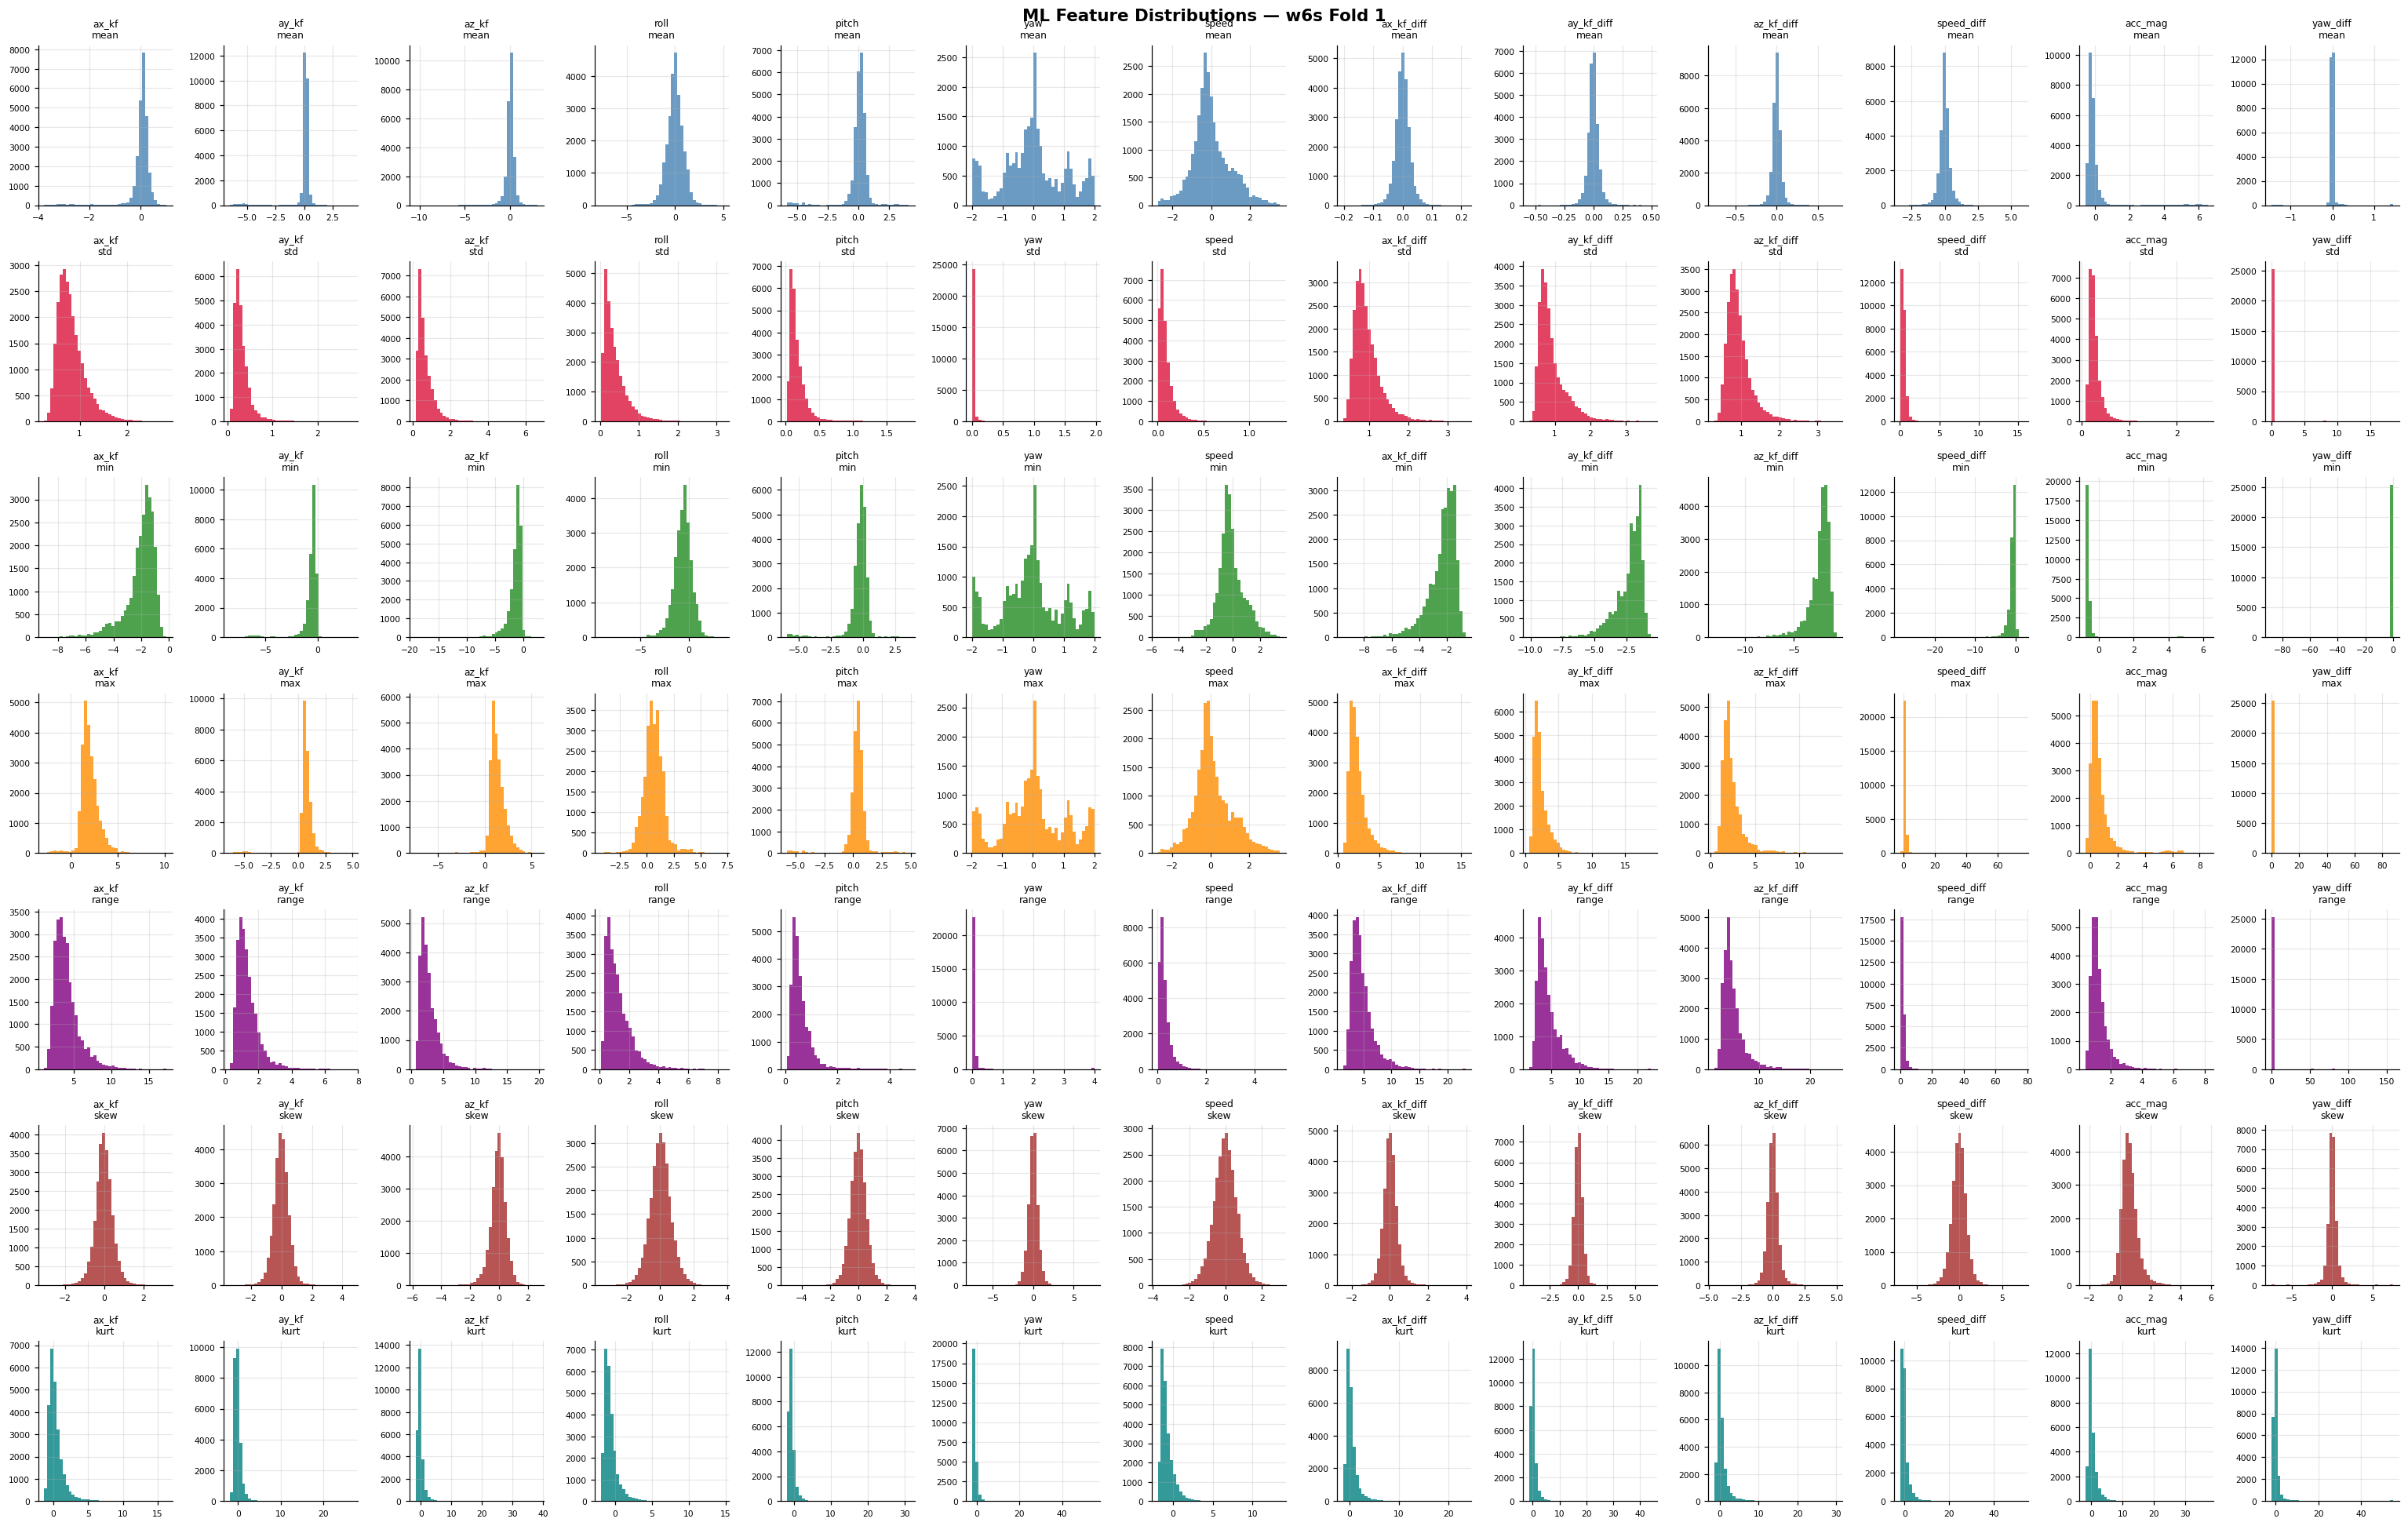

In [12]:
# Plot distribution of ML features grouped by statistic type
window = 'w6s'
fold   = 1
base   = READY_DIR / window / f'fold{fold}' / 'ml'
X_train = np.load(base / 'X_train.npy')

# Grid must be 7 stats x 13 signals
fig, axes = plt.subplots(7, 13, figsize=(28, 18))
fig.suptitle(f'ML Feature Distributions — {window} Fold {fold}',
             fontsize=14, fontweight='bold')

stat_colors = {
    'mean':  'steelblue',
    'std':   'crimson',
    'min':   'forestgreen',
    'max':   'darkorange',
    'range': 'purple',
    'skew':  'brown',
    'kurt':  'teal'
}

for i, col in enumerate(ML_COL_NAMES):
    row = i // 13      # Which stat row
    col_idx = i % 13   # Which signal column
    stat = STATS[row]

    vals = X_train[:, i]
    axes[row, col_idx].hist(vals, bins=40,
                             color=stat_colors[stat], alpha=0.8,
                             edgecolor='none')
    
    feat_name = ML_STAT_FEATURES[col_idx]
    axes[row, col_idx].set_title(f'{feat_name}\n{stat}', fontsize=8)
    axes[row, col_idx].tick_params(labelsize=7)

plt.tight_layout()
plt.show()


---
## Part 3 — Summary Table

In [13]:
print('Window Count Summary — All Folds')
print('=' * 55)
print(f'{"Window":<8} {"Fold":<6} {"LSTM Train":>12} {"LSTM Test":>12} {"ML Train":>10} {"ML Test":>10}')
print('-' * 55)

for window in WINDOWS:
    for fold in range(1, N_FOLDS + 1):
        lstm_base = READY_DIR / window / f'fold{fold}' / 'lstm'
        ml_base   = READY_DIR / window / f'fold{fold}' / 'ml'

        y_lstm_train = np.load(lstm_base / 'y_train.npy')
        y_lstm_test  = np.load(lstm_base / 'y_test.npy')
        y_ml_train   = np.load(ml_base   / 'y_train.npy')
        y_ml_test    = np.load(ml_base   / 'y_test.npy')

        # LSTM and ML y arrays should be identical
        match = '✓' if np.array_equal(y_lstm_train, y_ml_train) else '✗ MISMATCH'

        print(f'  {window:<6}  {fold:<4}'
              f'  {len(y_lstm_train):>10}'
              f'  {len(y_lstm_test):>10}'
              f'  {len(y_ml_train):>8}'
              f'  {len(y_ml_test):>8}'
              f'  labels {match}')
    print()

print('labels ✓ = LSTM and ML y arrays are identical (correct)')

Window Count Summary — All Folds
Window   Fold     LSTM Train    LSTM Test   ML Train    ML Test
-------------------------------------------------------
  w6s     1          25554        4712     25554      4712  labels ✓
  w6s     2          25092        5174     25092      5174  labels ✓
  w6s     3          24983        5283     24983      5283  labels ✓
  w6s     4          24781        5485     24781      5485  labels ✓
  w6s     5          25080        5186     25080      5186  labels ✓
  w6s     6          25840        4426     25840      4426  labels ✓

labels ✓ = LSTM and ML y arrays are identical (correct)


In [14]:
print('Final Verification Checklist')
print('=' * 50)

checks = []

for window in WINDOWS:
    for fold in range(1, N_FOLDS + 1):
        lstm_base = READY_DIR / window / f'fold{fold}' / 'lstm'
        ml_base   = READY_DIR / window / f'fold{fold}' / 'ml'

        X_lstm = np.load(lstm_base / 'X_train.npy')
        X_ml   = np.load(ml_base   / 'X_train.npy')
        y_lstm = np.load(lstm_base / 'y_train.npy')
        y_ml   = np.load(ml_base   / 'y_train.npy')

        lstm_shape_ok = X_lstm.ndim == 3 and X_lstm.shape[2] == 13
        ml_shape_ok   = X_ml.ndim == 2 and X_ml.shape[1] == 91
        labels_match  = np.array_equal(y_lstm, y_ml)
        no_nan_lstm   = not np.isnan(X_lstm).any()
        no_nan_ml     = not np.isnan(X_ml).any()

        checks.append({
            'window': window, 'fold': fold,
            'lstm_shape': lstm_shape_ok,
            'ml_shape':   ml_shape_ok,
            'labels':     labels_match,
            'no_nan_lstm': no_nan_lstm,
            'no_nan_ml':   no_nan_ml,
        })

print(f'{"Window":<8} {"Fold":<6} {"LSTM shape":>12} {"ML shape":>10} {"Labels":>8} {"No NaN LSTM":>12} {"No NaN ML":>10}')
print('-' * 70)

all_passed = True
for c in checks:
    ok = all([c['lstm_shape'], c['ml_shape'], c['labels'], c['no_nan_lstm'], c['no_nan_ml']])
    if not ok:
        all_passed = False
    sym = lambda b: '✓' if b else '✗'
    print(f'  {c["window"]:<6}  {c["fold"]:<4}'
          f'  {sym(c["lstm_shape"]):>10}'
          f'  {sym(c["ml_shape"]):>10}'
          f'  {sym(c["labels"]):>8}'
          f'  {sym(c["no_nan_lstm"]):>12}'
          f'  {sym(c["no_nan_ml"]):>10}')

print()
if all_passed:
    print('ALL CHECKS PASSED — Data is ready for training.')
else:
    print('SOME CHECKS FAILED — Fix issues before training.')

Final Verification Checklist
Window   Fold     LSTM shape   ML shape   Labels  No NaN LSTM  No NaN ML
----------------------------------------------------------------------
  w6s     1              ✓           ✓         ✓             ✓           ✓
  w6s     2              ✓           ✓         ✓             ✓           ✓
  w6s     3              ✓           ✓         ✓             ✓           ✓
  w6s     4              ✓           ✓         ✓             ✓           ✓
  w6s     5              ✓           ✓         ✓             ✓           ✓
  w6s     6              ✓           ✓         ✓             ✓           ✓

ALL CHECKS PASSED — Data is ready for training.
